In [1]:
!pip install -q boto3 pandas pyarrow s3fs duckdb plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.1/65.1 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import boto3

s3 = boto3.client(
    "s3",
    region_name=os.getenv("AWS_DEFAULT_REGION"),
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY")
)

BUCKET = "factored-datathon-2026-s3-157725502942-us-east-2-an"
PREFIX = "data/transactions/"

paginator = s3.get_paginator("list_objects_v2")

transaction_files = []

for page in paginator.paginate(
    Bucket=BUCKET,
    Prefix=PREFIX
):
    for obj in page.get("Contents", []):
        transaction_files.append({
            "key": obj["Key"],
            "size_mb": obj["Size"] / 1024 / 1024
        })

print(f"Total archivos: {len(transaction_files)}")

for obj in transaction_files[:20]:
    print(
        obj["key"],
        round(obj["size_mb"], 2),
        "MB"
    )

Buckets disponibles:
- ai-sdlc-context-engine-tfstate-tqklao
- amazon-sagemaker-157725502942-us-east-1-6w3nwv9iv1pbqf
- amazon-sagemaker-157725502942-us-east-1-cb804207e1c8
- ar-presentation-card
- ascend-integration-tfstate-nuho60
- bti-market-intelligence-linkedin-macro-test
- buddy-assignment
- case-study-assistant-tfstate-eiy2ov
- coding-agents-benchmark-tfstate-vxzcto
- databricks-bronze-20231113212214157200000004
- databricks-gold-20231113212214155700000002
- databricks-metastore-20231113212214155700000001
- databricks-raw-20231115231617223600000001
- databricks-s3-ingest-7a675-buddy--lambdazipsbucket-myc6qmw9acmn
- databricks-silver-20231113212214158800000005
- databricks-summit-tfstate-jzbb53
- datasage-data-s3-bucket
- datasage-tfstate-rgdh43
- de-databricks-boosting-tfstate-e528ee
- delete-douglas-ca-tfstate-dpn429
- delete-dummy-prj-12-state-20250902141446-6e6e776b
- delete-dummy-prj-21-state-20250902165733-64a0f70f
- delete-dummy-prj-22-tfstate-sfyn53
- delete-dummy-prj-tes

In [5]:
response = s3.list_objects_v2(
    Bucket="factored-datathon-2026-s3-157725502942-us-east-2-an",
    Prefix="data/transactions/"
)

for obj in response.get("Contents", []):
    print(
        obj["Key"],
        round(obj["Size"] / 1024 / 1024, 2),
        "MB"
    )

data/transactions/year=2023/month=06/day=17/transactions_20230617.csv 0.5 MB
data/transactions/year=2023/month=06/day=18/transactions_20230618.csv 0.51 MB
data/transactions/year=2023/month=06/day=19/transactions_20230619.csv 0.72 MB
data/transactions/year=2023/month=06/day=20/transactions_20230620.csv 0.74 MB
data/transactions/year=2023/month=06/day=21/transactions_20230621.csv 0.85 MB
data/transactions/year=2023/month=06/day=22/transactions_20230622.csv 0.78 MB
data/transactions/year=2023/month=06/day=23/transactions_20230623.csv 0.93 MB
data/transactions/year=2023/month=06/day=24/transactions_20230624.csv 0.5 MB
data/transactions/year=2023/month=06/day=25/transactions_20230625.csv 0.5 MB
data/transactions/year=2023/month=06/day=26/transactions_20230626.csv 0.87 MB
data/transactions/year=2023/month=06/day=27/transactions_20230627.csv 0.78 MB
data/transactions/year=2023/month=06/day=28/transactions_20230628.csv 0.73 MB
data/transactions/year=2023/month=06/day=29/transactions_20230629.c

#TRANSACTIONS


In [7]:
import pandas as pd

# Se corrigió el nombre del bucket agregando el sufijo '-an'
path = "s3://factored-datathon-2026-s3-157725502942-us-east-2-an/data/transactions/year=2023/month=06/day=17/transactions_20230617.csv"

tx = pd.read_csv(path)

print("Shape:", tx.shape)
display(tx.head())

Shape: (2886, 22)


,transaction_id,transaction_date,process_date,product_id,customer_id,transaction_type,transaction_category,amount,currency,amount_usd,...,merchant_name,merchant_category,transaction_country,transaction_city,transaction_status,response_code,is_fraud,fraud_score,latitude,longitude
0,TRX-7I07NJ7LT0TPC5YC33UL,2023-06-17 14:54:58,2023-06-17,PRD-7EFOVFRUE3UQ,CLI-DRS40C485MAB,Deposit,NaN,3695.53,USD,NaN,...,NaN,NaN,México,Monterrey,Approved,0.0,False,0.89,NaN,NaN
1,TRX-5COPO2MJ8G9XO7BR2TSE,2023-06-17 14:17:51,2023-06-17,PRD-HMGUZQXKE413,CLI-RIO7AY0XG4MY,Withdrawal,NaN,492.91,USD,NaN,...,NaN,NaN,México,Tijuana,Approved,0.0,False,25.02,NaN,NaN
2,TRX-SF2DZJYU0POJ9N4FGYV9,2023-06-18 03:17:02,2023-06-17,PRD-Z9VH3WRVEJP5,CLI-NRCMAC93SWIH,Withdrawal,NaN,1200383.22,COP,300.10,...,NaN,NaN,Argentina,Mendoza,Approved,0.0,False,NaN,NaN,NaN
3,TRX-VY3H2RR4HJ9VF7JQ7BZN,2023-06-18 03:48:24,2023-06-17,PRD-3963712YA073,CLI-NRS8RG7UHLKI,Withdrawal,NaN,10272.09,ARS,29.35,...,NaN,NaN,Argentina,Buenos Aires,Approved,0.0,False,1.74,NaN,NaN
4,TRX-8HE3NCEV1NN2QS36J56G,2023-06-17 07:08:37,2023-06-17,PRD-S6CRGMNKOGAT,CLI-M1CZMRQ8CW3G,Transfer,NaN,801.49,USD,NaN,...,NaN,NaN,México,Guadalajara,Approved,0.0,False,NaN,NaN,NaN


In [8]:
tx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2886 entries, 0 to 2885
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_id        2886 non-null   object 
 1   transaction_date      2886 non-null   object 
 2   process_date          2886 non-null   object 
 3   product_id            2886 non-null   object 
 4   customer_id           2886 non-null   object 
 5   transaction_type      2886 non-null   object 
 6   transaction_category  1111 non-null   object 
 7   amount                2886 non-null   float64
 8   currency              2886 non-null   object 
 9   amount_usd            1249 non-null   float64
 10  channel               2886 non-null   object 
 11  branch_id             886 non-null    object 
 12  merchant_name         635 non-null    object 
 13  merchant_category     634 non-null    object 
 14  transaction_country   2886 non-null   object 
 15  transaction_city     

In [9]:
tx.columns.tolist()

['transaction_id',
 'transaction_date',
 'process_date',
 'product_id',
 'customer_id',
 'transaction_type',
 'transaction_category',
 'amount',
 'currency',
 'amount_usd',
 'channel',
 'branch_id',
 'merchant_name',
 'merchant_category',
 'transaction_country',
 'transaction_city',
 'transaction_status',
 'response_code',
 'is_fraud',
 'fraud_score',
 'latitude',
 'longitude']

In [10]:
print(tx.isna().sum().sort_values(ascending=False))

latitude                2320
longitude               2318
merchant_category       2252
merchant_name           2251
branch_id               2000
transaction_category    1775
amount_usd              1637
fraud_score              554
transaction_city         272
response_code            134
transaction_date           0
transaction_id             0
product_id                 0
process_date               0
transaction_type           0
customer_id                0
amount                     0
currency                   0
channel                    0
transaction_country        0
transaction_status         0
is_fraud                   0
dtype: int64


In [13]:
display(
    tx.groupby("transaction_status")
      .agg(
          transactions=("transaction_id", "count"),
          amount_usd_missing=("amount_usd", lambda x: x.isna().sum()),
          category_missing=("transaction_category", lambda x: x.isna().sum()),
          merchant_missing=("merchant_name", lambda x: x.isna().sum())
      )
)

,transactions,amount_usd_missing,category_missing,merchant_missing
transaction_status,,,,
Approved,2653,1499,1633,2067
Declined,141,77,81,111
Pending,58,40,34,44
Reversed,34,21,27,29


In [12]:
display(
    tx.groupby("transaction_type")
      .agg(
          transactions=("transaction_id", "count"),
          amount_usd_missing=("amount_usd", lambda x: x.isna().sum()),
          category_missing=("transaction_category", lambda x: x.isna().sum())
      )
)

,transactions,amount_usd_missing,category_missing
transaction_type,,,
Adjustment,91,54,91
Deposit,400,231,400
Payment,488,285,23
Purchase,671,374,25
Transfer,593,327,593
Withdrawal,643,366,643


In [35]:
bucket = "factored-datathon-2026-s3-157725502942-us-east-2-an"
prefix = "data/transactions/"

paginator = s3.get_paginator("list_objects_v2")

transaction_files = []

for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
    for obj in page.get("Contents", []):
        if obj["Key"].endswith(".csv"):
            transaction_files.append(obj["Key"])

print("Archivos:", len(transaction_files))
print(transaction_files[:5])
print(transaction_files[-5:])

Archivos: 1097
['data/transactions/year=2023/month=06/day=17/transactions_20230617.csv', 'data/transactions/year=2023/month=06/day=18/transactions_20230618.csv', 'data/transactions/year=2023/month=06/day=19/transactions_20230619.csv', 'data/transactions/year=2023/month=06/day=20/transactions_20230620.csv', 'data/transactions/year=2023/month=06/day=21/transactions_20230621.csv']
['data/transactions/year=2026/month=06/day=13/transactions_20260613.csv', 'data/transactions/year=2026/month=06/day=14/transactions_20260614.csv', 'data/transactions/year=2026/month=06/day=15/transactions_20260615.csv', 'data/transactions/year=2026/month=06/day=16/transactions_20260616.csv', 'data/transactions/year=2026/month=06/day=17/transactions_20260617.csv']


In [36]:
import numpy as np
import pandas as pd

sample_files = [
    transaction_files[i]
    for i in np.linspace(
        0,
        len(transaction_files) - 1,
        min(30, len(transaction_files)),
        dtype=int
    )
]

print("Archivos seleccionados:", len(sample_files))

Archivos seleccionados: 30


In [38]:
dfs = []

for key in sample_files:
    path = f"s3://{bucket}/{key}"
    df = pd.read_csv(path)
    dfs.append(df)

transactions_sample = pd.concat(
    dfs,
    ignore_index=True
)

print(transactions_sample.shape)
display(transactions_sample.head())

(121672, 22)


,transaction_id,transaction_date,process_date,product_id,customer_id,transaction_type,transaction_category,amount,currency,amount_usd,...,merchant_name,merchant_category,transaction_country,transaction_city,transaction_status,response_code,is_fraud,fraud_score,latitude,longitude
0,TRX-7I07NJ7LT0TPC5YC33UL,2023-06-17 14:54:58,2023-06-17,PRD-7EFOVFRUE3UQ,CLI-DRS40C485MAB,Deposit,NaN,3695.53,USD,NaN,...,NaN,NaN,México,Monterrey,Approved,0.0,False,0.89,NaN,NaN
1,TRX-5COPO2MJ8G9XO7BR2TSE,2023-06-17 14:17:51,2023-06-17,PRD-HMGUZQXKE413,CLI-RIO7AY0XG4MY,Withdrawal,NaN,492.91,USD,NaN,...,NaN,NaN,México,Tijuana,Approved,0.0,False,25.02,NaN,NaN
2,TRX-SF2DZJYU0POJ9N4FGYV9,2023-06-18 03:17:02,2023-06-17,PRD-Z9VH3WRVEJP5,CLI-NRCMAC93SWIH,Withdrawal,NaN,1200383.22,COP,300.10,...,NaN,NaN,Argentina,Mendoza,Approved,0.0,False,NaN,NaN,NaN
3,TRX-VY3H2RR4HJ9VF7JQ7BZN,2023-06-18 03:48:24,2023-06-17,PRD-3963712YA073,CLI-NRS8RG7UHLKI,Withdrawal,NaN,10272.09,ARS,29.35,...,NaN,NaN,Argentina,Buenos Aires,Approved,0.0,False,1.74,NaN,NaN
4,TRX-8HE3NCEV1NN2QS36J56G,2023-06-17 07:08:37,2023-06-17,PRD-S6CRGMNKOGAT,CLI-M1CZMRQ8CW3G,Transfer,NaN,801.49,USD,NaN,...,NaN,NaN,México,Guadalajara,Approved,0.0,False,NaN,NaN,NaN


# CUSTOMERS

In [15]:
customers = pd.read_csv(
    "s3://factored-datathon-2026-s3-157725502942-us-east-2-an/data/customers.csv"
)

print("Shape:", customers.shape)
display(customers.head())

Shape: (150000, 27)


,customer_id,document_number,document_type,first_name,last_name,date_of_birth,gender,email,mobile_phone,landline_phone,...,credit_score,estimated_monthly_income,occupation,marital_status,education_level,registration_date,registration_branch_id,customer_status,last_updated,accepts_marketing
0,CLI-G4X2AMVD62NR,G8637940,Pasaporte,Samuel Andrés,Díaz Pérez,1967-06-18,M,samueldiaz@protonmail.com,+57 315 564 6977,+57 4 314 5374,...,701.0,24678431.94,Administrative,Married,University,2021-07-30 05:39:39,SUC-7R3DCC91,Active,2021-08-15 05:39:39,False
1,CLI-F2DZJYU0POJ9,42388496,DNI,Javier,Campos Mendoza,1976-04-16,M,jcampos@gmail.com,+54 9 31 8433 1053,+54 44 9201 3927,...,576.0,NaN,Homemaker,Single,NaN,2022-12-09 13:10:47,SUC-7ZI313MS,Active,2023-05-15 13:10:47,True
2,CLI-8WU28O74XKHS,89638346,DNI,Alejandro Catalina,Hernández Rojas,1995-02-09,O,alejandro.hernandez827@outlook.com,+54 9 95 8062 6804,NaN,...,657.0,28495.40,Teacher,Divorced,NaN,2024-04-06 16:26:17,SUC-48CL872M,Active,2025-01-12 16:26:17,True
3,CLI-IU5Y26LO84W8,26064746,DNI,José,Morales Flores,1948-06-05,O,jose.morales@live.com,+54 9 95 9565 6183,NaN,...,598.0,37284.11,Employee,NaN,High School,2024-09-10 17:43:08,SUC-5AYKJQ2L,Inactive,2024-10-15 17:43:08,True
4,CLI-C4Z5FPK4YO51,12411824,DNI,Jesús,Ruiz Herrera,1985-07-22,M,jesusruiz@yahoo.com,+54 9 50 6974 1653,NaN,...,594.0,25257.93,Lawyer,Married,Elementary,2026-03-03 23:05:30,SUC-UI9W1MT1,Active,2026-09-29 23:05:30,True


In [16]:
display(customers.isna().sum().sort_values(ascending=False))

,0
landline_phone,75053
detected_accent,44817
estimated_monthly_income,30033
credit_score,22492
education_level,17952
postal_code,15044
occupation,15039
marital_status,11955
address,7370
mobile_phone,4707


# Products

In [17]:
products = pd.read_csv(
    "s3://factored-datathon-2026-s3-157725502942-us-east-2-an/data/products.csv"
)

print("Shape:", products.shape)
display(products.head())

Shape: (400000, 17)


,product_id,customer_id,product_type,product_number,currency,current_balance,credit_limit,interest_rate,opening_date,expiration_date,opening_branch_id,product_status,opening_channel,has_linked_app,days_past_due,last_transaction_date,last_updated
0,PRD-LT0TPC5YC33U,CLI-0Y0HOQ83ZSO4,Cuenta Corriente,4332181960,COP,13026299.27,NaN,0.32,2025-03-18,NaN,SUC-E1VTXGEU,Active,Web,True,NaN,2025-07-08 17:19:16,2025-12-25 00:57:58
1,PRD-L6Q5DZNKOUR8,CLI-E33FWYXNBBAQ,Tarjeta Débito,4959310341316475,USD,961.65,NaN,0.00,2022-08-12,2025-08-11,SUC-LQXENAY2,Active,App,True,NaN,2026-03-31 15:32:04,2023-01-20 12:56:06
2,PRD-9JXO4VRRCA50,CLI-5A1RQN103PRE,Tarjeta Crédito,4672423884969653,USD,1173.14,8489.22,22.32,2018-12-27,2023-12-26,SUC-TVNO2KL5,Active,Branch,True,0.0,2024-03-27 23:15:23,2019-11-12 03:59:31
3,PRD-H2RR4HJ9VF7J,CLI-B2YEBULXPM7U,Tarjeta Débito,4893252880957015,USD,789.55,NaN,0.00,2021-02-22,2024-02-22,SUC-QZU3WHKF,Closed,Branch,False,NaN,NaN,2021-04-24 02:06:32
4,PRD-K8HE3NCEV1NN,CLI-IS8ZF6LQOPAC,Cuenta Corriente,5098393010,COP,11151672.05,NaN,0.31,2022-03-02,NaN,SUC-4BEKYT6U,Active,Branch,True,NaN,2022-11-27 23:22:14,2022-10-17 02:34:47


In [18]:
display(products.isna().sum().sort_values(ascending=False))

,0
credit_limit,274683
days_past_due,274650
expiration_date,266839
last_transaction_date,94277
interest_rate,40066
product_id,0
currency,0
customer_id,0
product_type,0
opening_date,0


In [19]:
print("Tipos de producto:")
display(products["product_type"].value_counts())

Tipos de producto:


,count
product_type,
Cuenta Ahorro,120203
Tarjeta Crédito,100102
Cuenta Corriente,99979
Tarjeta Débito,39938
Préstamo Personal,19960
Préstamo Hipotecario,11910
Inversión,5859
Seguro,2049


In [20]:
print("Estados:")
display(products["product_status"].value_counts())

Estados:


,count
product_status,
Active,339965
Closed,32039
Blocked,19935
Suspended,8061


In [21]:
display(
    products.groupby("product_type")
    .agg(
        products=("product_id", "count"),
        customers=("customer_id", "nunique"),
        avg_balance=("current_balance", "mean"),
        credit_limit_missing=("credit_limit", lambda x: x.isna().mean() * 100),
        interest_rate_missing=("interest_rate", lambda x: x.isna().mean() * 100)
    )
    .sort_values("customers", ascending=False)
)

,products,customers,avg_balance,credit_limit_missing,interest_rate_missing
product_type,,,,,
Cuenta Ahorro,120203,82695,5.718001e+06,100.000000,9.991431
Tarjeta Crédito,100102,73177,1.731650e+06,5.053845,9.969831
Cuenta Corriente,99979,72843,2.868390e+06,100.000000,10.008102
Tarjeta Débito,39938,35015,9.304237e+05,100.000000,10.045571
Préstamo Personal,19960,18615,9.031541e+06,4.969940,10.085170
Préstamo Hipotecario,11910,11417,9.168486e+07,5.071369,10.109152
Inversión,5859,5750,1.750360e+07,100.000000,10.820959
Seguro,2049,2036,0.000000e+00,100.000000,10.102489


In [22]:
products_per_customer = (
    products.groupby("customer_id")["product_id"]
    .nunique()
)

display(products_per_customer.describe())

print(
    "Clientes con 1 producto:",
    (products_per_customer == 1).sum()
)

print(
    "Clientes con 2 productos:",
    (products_per_customer == 2).sum()
)

print(
    "Clientes con 3+ productos:",
    (products_per_customer >= 3).sum()
)

,product_id
count,139578.000000
mean,2.865781
std,1.516137
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,12.000000


Clientes con 1 producto: 27847
Clientes con 2 productos: 36943
Clientes con 3+ productos: 74788


In [23]:
# 1. ¿Qué estados tienen los productos?
display(products["product_status"].value_counts(dropna=False))

# 2. Productos por cliente
products_per_customer = (
    products.groupby("customer_id")["product_id"]
    .nunique()
    .value_counts()
    .sort_index()
)

display(products_per_customer)

# 3. ¿Cuántos clientes tienen cada tipo de producto?
product_customers = (
    products.groupby("product_type")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
)

display(product_customers)

# 4. Penetración de cada producto
total_customers = customers["customer_id"].nunique()

penetration = (
    product_customers
    .div(total_customers)
    .mul(100)
    .sort_values(ascending=False)
)

display(
    penetration.rename("penetration_pct").to_frame()
)

,count
product_status,
Active,339965
Closed,32039
Blocked,19935
Suspended,8061


,count
product_id,
1,27847
2,36943
3,33112
4,21822
5,11691
6,5259
7,1947
8,690
9,198


,customer_id
product_type,
Cuenta Ahorro,82695
Tarjeta Crédito,73177
Cuenta Corriente,72843
Tarjeta Débito,35015
Préstamo Personal,18615
Préstamo Hipotecario,11417
Inversión,5750
Seguro,2036


,penetration_pct
product_type,
Cuenta Ahorro,55.130000
Tarjeta Crédito,48.784667
Cuenta Corriente,48.562000
Tarjeta Débito,23.343333
Préstamo Personal,12.410000
Préstamo Hipotecario,7.611333
Inversión,3.833333
Seguro,1.357333


In [24]:
# Productos activos por cliente
active_products = products[
    products["product_status"] == "Active"
].copy()

portfolio = pd.crosstab(
    active_products["customer_id"],
    active_products["product_type"]
)

portfolio = (portfolio > 0).astype(int)

display(portfolio.head())

product_type,Cuenta Ahorro,Cuenta Corriente,Inversión,Préstamo Hipotecario,Préstamo Personal,Seguro,Tarjeta Crédito,Tarjeta Débito
customer_id,,,,,,,,
CLI-000RJ6XJD6RO,1,1,0,0,0,0,0,1
CLI-000W7FWO8212,0,1,0,0,0,0,0,0
CLI-0011WR7BFJZ8,0,1,0,0,0,0,0,0
CLI-001AVI5RHIYA,1,1,0,0,0,0,1,0
CLI-001FRQ98IGKY,1,1,0,0,0,0,1,0


In [25]:
from itertools import combinations

product_types = portfolio.columns.tolist()

pair_counts = []

for a, b in combinations(product_types, 2):
    customers_with_both = (
        (portfolio[a] == 1) &
        (portfolio[b] == 1)
    ).sum()

    pair_counts.append({
        "product_a": a,
        "product_b": b,
        "customers": customers_with_both
    })

pairs = (
    pd.DataFrame(pair_counts)
    .sort_values("customers", ascending=False)
)

display(pairs.head(15))

,product_a,product_b,customers
0,Cuenta Ahorro,Cuenta Corriente,32160
5,Cuenta Ahorro,Tarjeta Crédito,32048
11,Cuenta Corriente,Tarjeta Crédito,27960
6,Cuenta Ahorro,Tarjeta Débito,14972
27,Tarjeta Crédito,Tarjeta Débito,13025
12,Cuenta Corriente,Tarjeta Débito,13002
3,Cuenta Ahorro,Préstamo Personal,7927
23,Préstamo Personal,Tarjeta Crédito,6942
9,Cuenta Corriente,Préstamo Personal,6803
2,Cuenta Ahorro,Préstamo Hipotecario,4858


In [26]:
products.groupby("product_type")["product_id"].nunique().sort_values(
    ascending=False
)

products.groupby("product_type")["product_id"].agg(
    ["nunique", "count"]
)

products[
    ["product_id", "product_type", "credit_limit",
     "interest_rate", "current_balance"]
].head(20)

,product_id,product_type,credit_limit,interest_rate,current_balance
0,PRD-LT0TPC5YC33U,Cuenta Corriente,NaN,0.32,13026299.27
1,PRD-L6Q5DZNKOUR8,Tarjeta Débito,NaN,0.00,961.65
2,PRD-9JXO4VRRCA50,Tarjeta Crédito,8.489220e+03,22.32,1173.14
3,PRD-H2RR4HJ9VF7J,Tarjeta Débito,NaN,0.00,789.55
4,PRD-K8HE3NCEV1NN,Cuenta Corriente,NaN,0.31,11151672.05
5,PRD-DZ9SGFYZKP5A,Cuenta Ahorro,NaN,2.02,5259.57
6,PRD-8EOABR2GZZ27,Cuenta Corriente,NaN,0.36,2186.89
7,PRD-RM9QJF02VWJU,Tarjeta Crédito,1.711709e+08,31.65,5593497.21
8,PRD-VU8TGAS806BV,Cuenta Corriente,NaN,0.42,4517.00
9,PRD-XJPQOD2NBBUP,Cuenta Corriente,NaN,0.15,985840.36


# Graficos


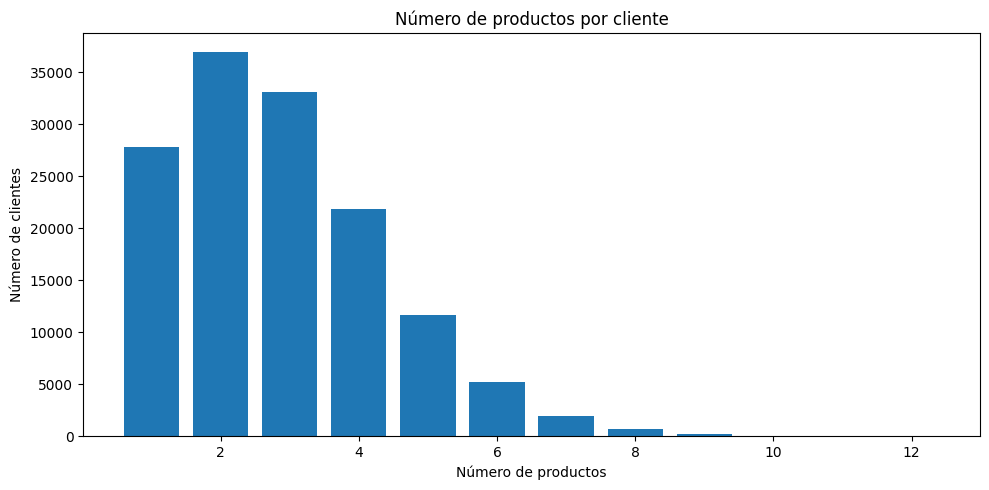

In [27]:
import matplotlib.pyplot as plt

products_per_customer = (
    products.groupby("customer_id")["product_id"]
    .nunique()
)

distribution = products_per_customer.value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(distribution.index, distribution.values)

plt.title("Número de productos por cliente")
plt.xlabel("Número de productos")
plt.ylabel("Número de clientes")

plt.tight_layout()
plt.show()

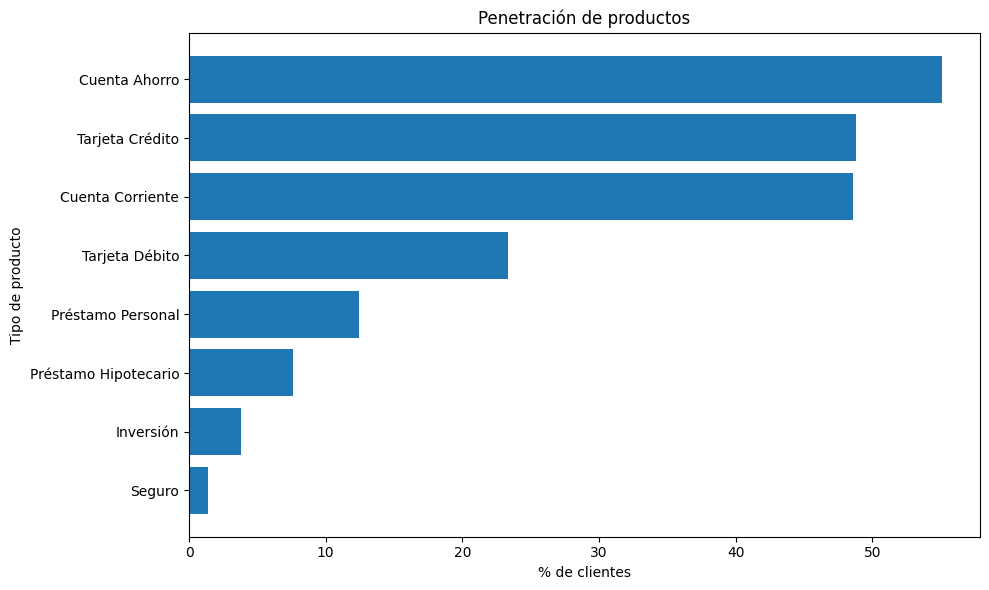

In [30]:
product_customers = (
    products.groupby("product_type")["customer_id"]
    .nunique()
)

total_customers = customers["customer_id"].nunique()

penetration = (
    product_customers
    .div(total_customers)
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,6))

plt.barh(
    penetration.index,
    penetration.values
)

plt.title("Penetración de productos")
plt.xlabel("% de clientes")
plt.ylabel("Tipo de producto")

plt.tight_layout()
plt.show()

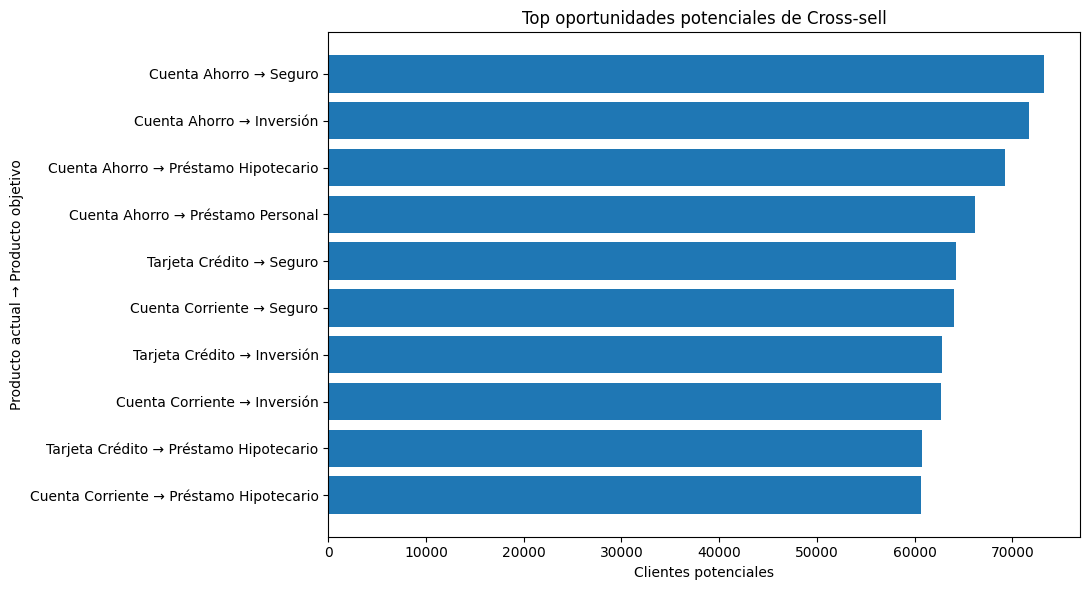

In [31]:
active_products = products[
    products["product_status"] == "Active"
].copy()

portfolio = pd.crosstab(
    active_products["customer_id"],
    active_products["product_type"]
)

portfolio = (portfolio > 0).astype(int)

from itertools import combinations
import pandas as pd

product_types = portfolio.columns.tolist()

cross_sell_opportunities = []

for source in product_types:
    for target in product_types:

        if source == target:
            continue

        opportunity = (
            (portfolio[source] == 1) &
            (portfolio[target] == 0)
        ).sum()

        cross_sell_opportunities.append({
            "source": source,
            "target": target,
            "customers": opportunity
        })

cross_sell = pd.DataFrame(cross_sell_opportunities)


top_cross_sell = (
    cross_sell
    .sort_values("customers", ascending=False)
    .head(10)
    .copy()
)

top_cross_sell["pair"] = (
    top_cross_sell["source"]
    + " → "
    + top_cross_sell["target"]
)

plt.figure(figsize=(11,6))

plt.barh(
    top_cross_sell["pair"][::-1],
    top_cross_sell["customers"][::-1]
)

plt.title("Top oportunidades potenciales de Cross-sell")
plt.xlabel("Clientes potenciales")
plt.ylabel("Producto actual → Producto objetivo")

plt.tight_layout()
plt.show()

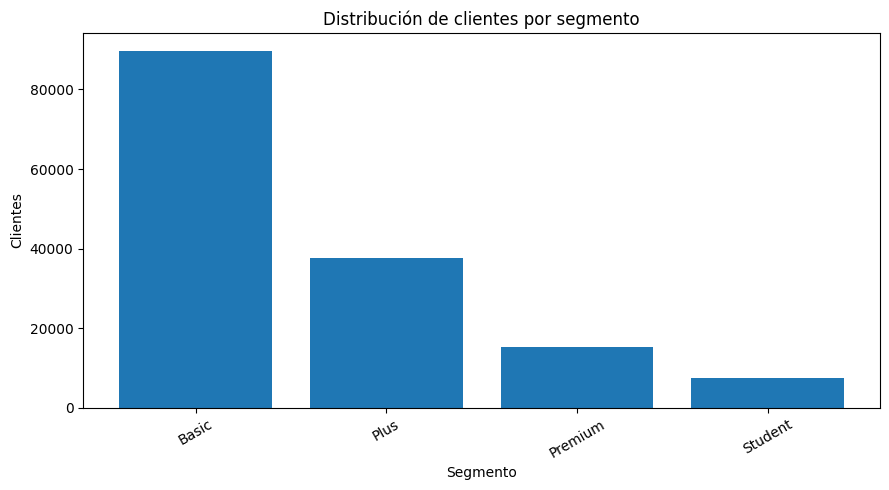

In [32]:
segment_counts = (
    customers["segment"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Distribución de clientes por segmento")
plt.xlabel("Segmento")
plt.ylabel("Clientes")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

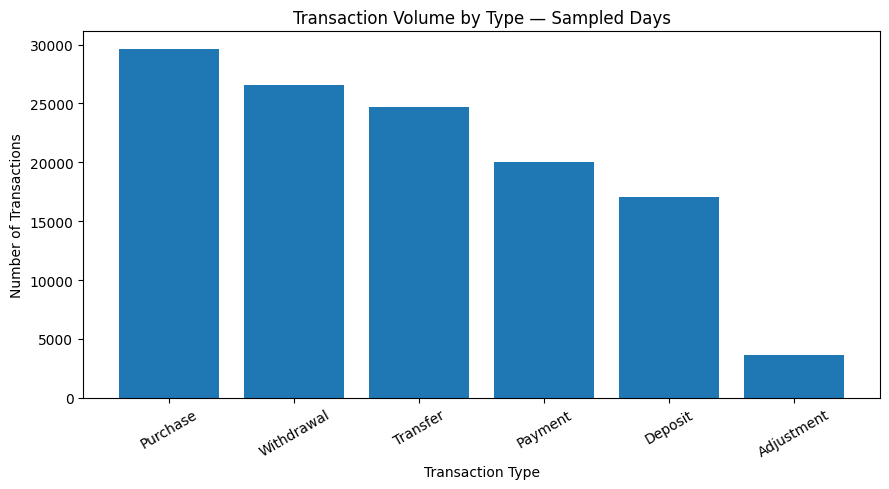

In [39]:
transaction_counts = (
    transactions_sample["transaction_type"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

plt.bar(
    transaction_counts.index,
    transaction_counts.values
)

plt.title("Transaction Volume by Type — Sampled Days")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

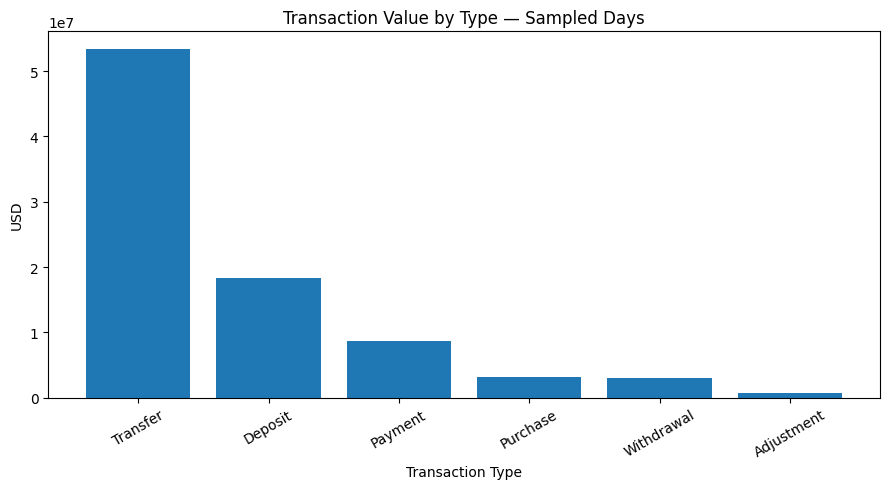

In [44]:
transaction_value = (
    transactions_sample
    .dropna(subset=["amount_usd"])
    .groupby("transaction_type")["amount_usd"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

plt.bar(
    transaction_value.index,
    transaction_value.values
)

plt.title("Transaction Value by Type — Sampled Days")
plt.xlabel("Transaction Type")
plt.ylabel("USD")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [42]:
customer_activity = (
    transactions_sample
    .groupby("customer_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_value_usd=("amount_usd", "sum"),
        active_days=("transaction_date", "nunique")
    )
    .reset_index()
)

display(customer_activity.head())

,customer_id,transaction_count,total_value_usd,active_days
0,CLI-000RJ6XJD6RO,4,4693.62,4
1,CLI-000W7FWO8212,1,0.00,1
2,CLI-003FFYLTJPU2,1,334.81,1
3,CLI-0073NMLHMZYW,1,336.11,1
4,CLI-007AY9KAHLA1,1,0.00,1


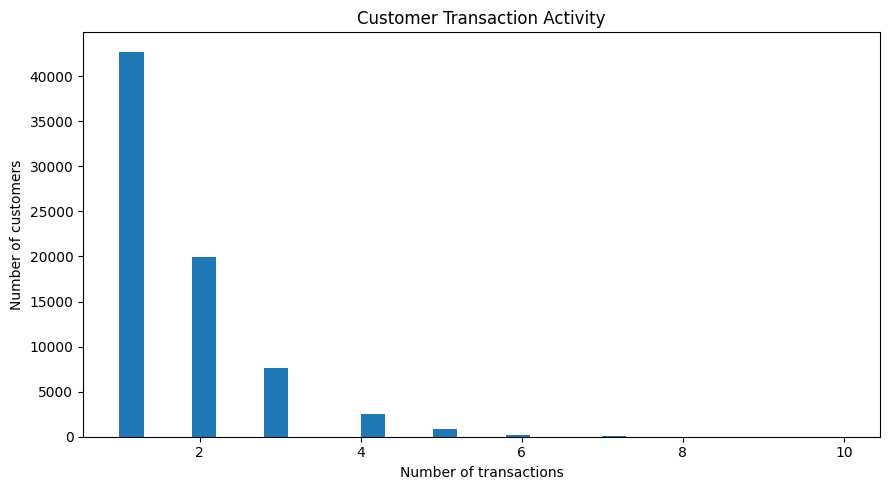

In [43]:
plt.figure(figsize=(9,5))

plt.hist(
    customer_activity["transaction_count"],
    bins=30
)

plt.title("Customer Transaction Activity")
plt.xlabel("Number of transactions")
plt.ylabel("Number of customers")

plt.tight_layout()
plt.show()